# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [1]:
import os

import imageio
import kagglehub
import pandas as pd
from PIL import Image



%matplotlib inline

In [2]:
from pathlib import Path

In [3]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


In [4]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\averkij\lfw-attributes\versions\1


In [5]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = Path(images_path)
ATTRIBUTES_PATH = Path(attrs_path).joinpath("lfw_attributes.txt")

In [6]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids.info())
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обрезка
    # dy - количество пикселей, обрезаемых сверху и снизу
    # dx - количество пикселей, обрезаемых слева и справа
    #
    # Изменение размера
    # dimx - ширина
    # dimy - высота

    images = df['photo_path'].apply(imageio.imread) \
        .apply(lambda img: img[dy:-dy, dx:-dx]) \
        .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [7]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset(dimx=44, dimy=44)

In [8]:

from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms


class AutoencoderDataset(Dataset):
    def __init__(self, images, indices, transform=None):
        """
        Args:
            images: numpy array в формате (N, H, W, C)
            indices: индексы для выборки
            transform: преобразования (включая ToTensor())
        """
        self.indices = indices
        self.images = images[indices]  # Выбираем данные по индексам (остаётся H x W x C)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # Получаем изображение в формате H x W x C

        if self.transform:
            image = self.transform(image)  # Применяем преобразования (включая ToTensor())
        else:
            # Если transform=None, делаем минимальное преобразование в тензор
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0  # HWC -> CHW и [0,255] -> [0,1]

        return image, image  # Для автоэнкодера input и target одинаковы


def get_dataloaders(images, batch_size=32, train_ratio=0.8, val_ratio=0.1):
    """
    Создает DataLoader'ы для train, validation и test

    Args:
        images: numpy array в формате (N, H, W, C)
        batch_size: размер батча
        train_ratio: доля тренировочных данных
        val_ratio: доля валидационных данных
    Returns:
        train_loader, val_loader, test_loader
    """
    # Проверка формата
    if images.ndim != 4 or images.shape[3] not in {1, 3}:
        raise ValueError("Ожидается формат (N, H, W, C), где C=1 или 3")

    # Разделение данных
    n_total = len(images)
    ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы
    train_size = int(train_ratio * n_total)
    val_size = int(val_ratio * n_total)
    tr, val, ts = np.split(ix, [train_size, train_size + val_size])

    # Стандартные преобразования (HWC -> CHW + нормализация)
    transform = transforms.Compose([
        transforms.ToTensor()  # Конвертирует numpy (H x W x C) в torch (C x H x W) и нормализует [0,1]
    ])

    # Создаем датасеты
    train_dataset = AutoencoderDataset(images, tr, transform=transform)
    val_dataset = AutoencoderDataset(images, val, transform=transform)
    test_dataset = AutoencoderDataset(images, ts, transform=transform)

    # Создаем DataLoader'ы
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [9]:
train_loader, val_loader, test_loader = get_dataloaders(images, batch_size=64)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


### VAE для картинок лиц

In [112]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.input_dim = 44 * 44 * 3
        self.linear1 = nn.Linear(self.input_dim, 1024)
        self.linear2 = nn.Linear(1024, latent_dims)  # mu
        self.linear3 = nn.Linear(1024, latent_dims)  # log(sigma)

        self.N = torch.distributions.Normal(0, 1)
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear2(x)
        log_sigma = self.linear3(x)
        sigma = torch.exp(log_sigma)
        z = mu + sigma * self.N.sample(mu.shape).to(x.device)
        self.kl = (sigma ** 2 + mu ** 2 - log_sigma - 1).sum() * 0.5
        return z


In [113]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.output_dim = 44 * 44 * 3
        self.linear1 = nn.Linear(latent_dims, 1024)
        self.linear2 = nn.Linear(1024, self.output_dim)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.view(-1, 3, 44, 44)


In [114]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [115]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    autoencoder.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0

        for x, _ in data:
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat) ** 2).sum() + autoencoder.encoder.kl
            loss.backward()
            opt.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        print(f'Epoch: {epoch}, Loss: {avg_loss:.4f}')

    return autoencoder


### Обучение VAE

In [116]:
latent_dims = 64

In [117]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [118]:
vae = VariationalAutoencoder(latent_dims).to(device)  # GPU
vae = train(vae, train_loader, epochs=20)

Epoch: 0, Loss: 8035.5958
Epoch: 1, Loss: 5795.2024
Epoch: 2, Loss: 5111.9922
Epoch: 3, Loss: 4792.0584
Epoch: 4, Loss: 4430.3766
Epoch: 5, Loss: 4213.4804
Epoch: 6, Loss: 4092.2441
Epoch: 7, Loss: 3942.1247
Epoch: 8, Loss: 3868.8301
Epoch: 9, Loss: 3821.6907
Epoch: 10, Loss: 3695.9313
Epoch: 11, Loss: 3654.4971
Epoch: 12, Loss: 3585.4575
Epoch: 13, Loss: 3546.2735
Epoch: 14, Loss: 3539.6252
Epoch: 15, Loss: 3469.8635
Epoch: 16, Loss: 3442.8240
Epoch: 17, Loss: 3432.2100
Epoch: 18, Loss: 3406.2975
Epoch: 19, Loss: 3376.3334


Проверим как работает реконструкция

In [119]:
def show_reconstructions(autoencoder, dataloader, device, num_images=8):
    autoencoder.eval()
    images_shown = 0

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            x_hat = autoencoder(x)

            x = x.cpu().numpy()
            x_hat = x_hat.cpu().numpy()

            for i in range(num_images):
                fig, axes = plt.subplots(1, 2, figsize=(4, 2))
                # Original
                axes[0].imshow(x[i].transpose(1, 2, 0))
                axes[0].set_title('Original')
                axes[0].axis('off')

                # Reconstruction
                axes[1].imshow(x_hat[i].transpose(1, 2, 0))
                axes[1].set_title('Reconstruction')
                axes[1].axis('off')

                plt.show()
                images_shown += 1

            break  # Показываем только один батч


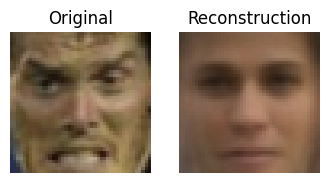

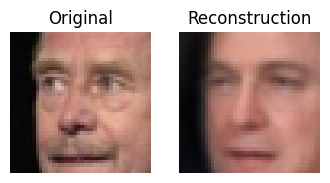

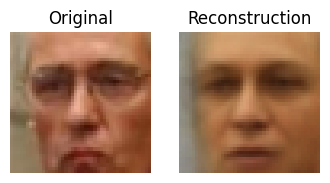

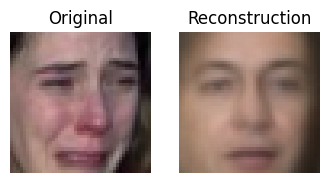

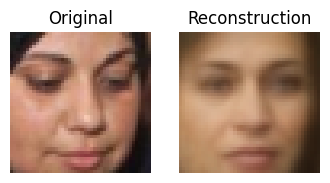

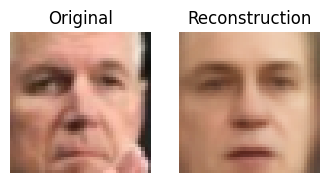

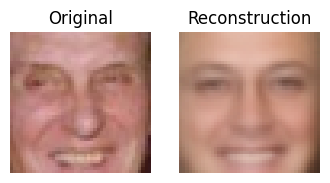

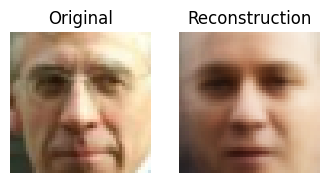

In [120]:
show_reconstructions(vae, test_loader, device='cpu')

### Выделим все вектора из латентного пространства

In [121]:
def extract_latent_vectors(autoencoder, dataloader, device):
    autoencoder.eval()
    latents = []

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            z = autoencoder.encoder(x)  # только кодирование
            latents.append(z.cpu())

    # Объединяем в один тензор
    latents = torch.cat(latents, dim=0)
    return latents

In [122]:
latents = extract_latent_vectors(vae, train_loader, device='cpu')
print(latents.shape)  # например: torch.Size([10000, latent_dim])


torch.Size([10514, 64])


### Обучение KNN для латентных векторов

In [123]:
from sklearn.neighbors import NearestNeighbors

# latents: [N, latent_dim]
nbrs = NearestNeighbors(n_neighbors=5, algorithm='auto', metric='euclidean').fit(latents)
distances, indices = nbrs.kneighbors(latents[:10])  # ищем для первых 10
print("Индексы ближайших:", indices)
print("Расстояния:", distances)

Индексы ближайших: [[   0 4541 6677 1669 2553]
 [   1  546 2065 6748   46]
 [   2 9771 2994 5127 8944]
 [   3 7587  538 1852 2090]
 [   4 7460  384 8985 9145]
 [   5 3788 8950  754 2364]
 [   6 7702 8037 2905  546]
 [   7 4623 1672 1223 7351]
 [   8 2708 1460 9767 3184]
 [   9 3135 4667  951 8500]]
Расстояния: [[1.19209290e-07 5.31665850e+00 5.39944935e+00 5.59374142e+00
  5.62406731e+00]
 [1.19209290e-07 4.96984148e+00 5.22679567e+00 5.28594828e+00
  5.34082699e+00]
 [1.19209290e-07 5.55858755e+00 5.73038769e+00 5.74961758e+00
  5.81896353e+00]
 [0.00000000e+00 5.40432882e+00 5.41305685e+00 5.51564312e+00
  5.56189442e+00]
 [0.00000000e+00 5.88498116e+00 6.09963417e+00 6.10610580e+00
  6.11977005e+00]
 [1.68587391e-07 5.85702515e+00 5.92330170e+00 6.02766514e+00
  6.16427088e+00]
 [1.19209290e-07 5.36857557e+00 5.46945667e+00 5.60606146e+00
  5.62770748e+00]
 [8.42936956e-08 5.36704969e+00 5.38333511e+00 5.45602608e+00
  5.45781708e+00]
 [0.00000000e+00 5.28633118e+00 5.37790680e+00 5

### Поиск похожих

In [128]:
def get_similar(image, autoencoder, knn_model, X_train, n_neighbors=5, device='cpu'):
    autoencoder.eval()

    # Переводим image в формат батча и на нужное устройство
    x = image.unsqueeze(0).to(device)

    with torch.no_grad():
        # Получаем латентный вектор
        code = autoencoder.encoder(x).cpu().numpy()

    # Поиск ближайших
    distances, indices = knn_model.kneighbors(code, n_neighbors=n_neighbors)

    # Получаем соответствующие изображения
    similar_images = torch.stack([X_train.dataset[i][0] for i in indices[0]])

    return distances[0], similar_images


In [166]:
n_neighbors = 5
knn_model = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto').fit(latents.numpy())

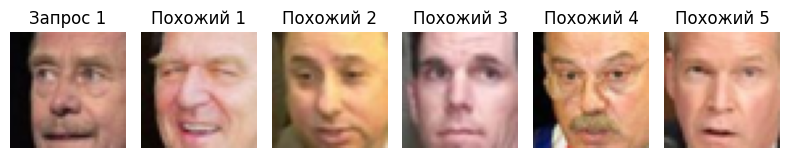

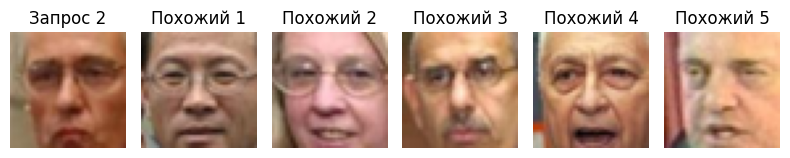

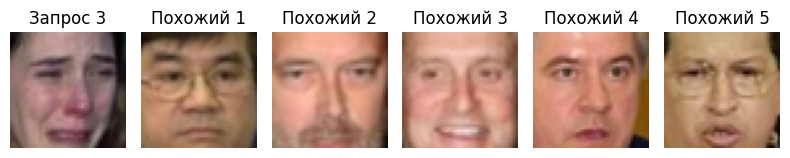

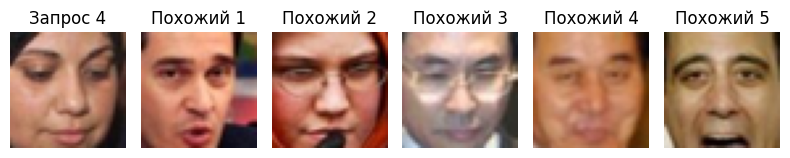

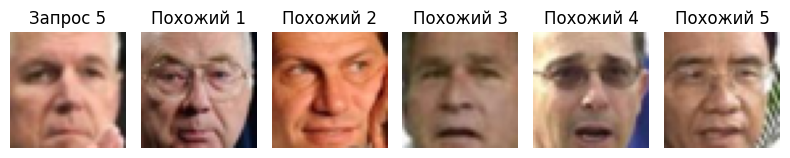

In [169]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img, _ = next(iter(test_loader))  # одна картинка из теста
map = {1: {3}, 3: {4}, 4: {2}, 5: {2, 3}}

for idx in range(1, 5 + 1):
    image = img[idx]
    distances, neighbors = get_similar(image, vae, knn_model, train_loader, device=device)

    plt.figure(figsize=(8, 2))

    ax = plt.subplot(1, n_neighbors + 1, 1)
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"Запрос {idx}")
    ax.axis('off')

    # Похожие картинки
    for i in range(n_neighbors):
        ax_sim = plt.subplot(1, n_neighbors + 1, i + 2)
        ax_sim.imshow(neighbors[i].permute(1, 2, 0))
        ax_sim.set_title(f"Похожий {i + 1}")
        ax_sim.axis('off')

    plt.tight_layout()
    plt.show()


> Модель довольно хорошо улавливает часть особенностей изображения. Возможно точно похожих картинок мало, но поиск работает эффективно даже с первого раза.